Measure first-order interest rate sensitivity

Measure second-order sensitivity

Understand duration as a weighted average maturity

Calculate bond and portfolio risk

Analyse exposure to specific points on the yield curve

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import CubicSpline

In [64]:
from pathlib import Path

ROOT = Path.cwd().parent

In [65]:
curve = pd.read_csv(ROOT / "data/continuous_zero_curve.csv")
portfolio = pd.read_csv(ROOT / "data/sample_portfolio.csv")

portfolio

,Bond,Maturity,Face,Coupon,Unit Price,Market Value,Weight
0,2Y,2,2000000.0,4.20,99.886010,1.997720e+06,0.201218
1,5Y,5,3000000.0,4.27,99.554418,2.986633e+06,0.300825
2,7Y,7,1500000.0,4.37,99.342777,1.490142e+06,0.150093
3,10Y,10,2500000.0,4.49,98.961077,2.474027e+06,0.249193
4,20Y,20,1000000.0,4.95,97.961892,9.796189e+05,0.098671


In [66]:
spot_curve = CubicSpline(
    curve["Years"],
    curve["Spot"]
)

In [67]:
def discount_factor(t):

    r = spot_curve(t) / 100

    return 1 / (1 + r)**t


def cashflows(maturity, coupon_rate, freq = 2, face = 100):

    periods = int(maturity * freq)

    payment = (coupon_rate / 100 * face / freq)

    times = np.arange(1, periods+1) / freq

    cashflows = np.full(
        periods,
        payment
    )

    cashflows[-1] += face

    return times, cashflows

def price_bond(maturity, coupon_rate, face = 100, frequency = 2):

    times, cf = cashflows(maturity, coupon_rate, frequency,face)

    dfs = discount_factor(times)

    return np.sum(cf * dfs)

In [68]:
# Macaulay duration
def macaulay_duration(maturity, coupon_rate, face = 100, frequency = 2):

    times, cf = cashflows(maturity, coupon_rate, frequency, face)

    r = spot_curve(times)/100

    df = 1 / (1 + r) ** times

    pv = cf * df

    price = pv.sum()

    duration = np.sum(times * pv) / price

    return duration


In [69]:
# Modified duration
def modified_duration(maturity, coupon_rate, frequency = 2):

    y = coupon_rate / 100

    D = macaulay_duration(maturity, coupon_rate, frequency = frequency)

    return D / (1 + y / frequency)

In [70]:
# Convexity
def convexity(maturity, coupon_rate, face = 100, frequency = 2):

    times, cf = cashflows(maturity, coupon_rate, frequency, face)

    r = spot_curve(times)/100

    df = 1/(1 + r) ** times

    pv = cf * df

    price = pv.sum()

    conv = np.sum(pv * times * (times + 1 /frequency)
    )

    conv /= (price * (1 + r[-1] / frequency) ** 2)

    return conv

In [71]:
# Numerical approximation check
def shift_curve(curve, shift_bp):

    shocked = curve.copy()

    shocked["Spot"] += shift_bp / 100

    return shocked

from scipy.interpolate import CubicSpline

def price_bond_curve(
    maturity,
    coupon_rate,
    curve,
    face=100,
    frequency=2
):

    spline = CubicSpline(
        curve["Years"],
        curve["Spot"]
    )

    times, cf = cashflows(
        maturity,
        coupon_rate,
        frequency,
        face
    )

    spot = spline(times) / 100

    discount = 1 / (1 + spot) ** times

    return np.sum(cf * discount)

maturity = 10
coupon = 4.5

P0 = price_bond_curve(
    maturity,
    coupon,
    curve
)

curve_up = shift_curve(curve, 1)
curve_down = shift_curve(curve, -1)

P_up = price_bond_curve(
    maturity,
    coupon,
    curve_up
)

P_down = price_bond_curve(
    maturity,
    coupon,
    curve_down
)

delta_y = 0.0001

numerical_duration = (
    P_down - P_up
) / (
    2 * P0 * delta_y
)

analytical_duration = modified_duration(
    maturity,
    coupon
)

print(f"Numerical Duration: {numerical_duration:.4f}")
print(f"Analytical Duration: {analytical_duration:.4f}")

Numerical Duration: 7.7730
Analytical Duration: 7.9572


In [72]:
curve_100bp = shift_curve(curve, 100)

P_actual = price_bond_curve(
    maturity,
    coupon,
    curve_100bp
)

delta_y = 0.01

P_duration = (
    P0
    *
    (
        1
        - analytical_duration * delta_y
    )
)

print(f"Original Price     : {P0:.4f}")
print(f"Actual Price (+100bp): {P_actual:.4f}")
print(f"Duration Estimate    : {P_duration:.4f}")

Original Price     : 99.0410
Actual Price (+100bp): 91.7059
Duration Estimate    : 91.1601


In [73]:
# DV01 / PV01
def dv01(maturity, coupon_rate, curve):

    P0 = price_bond_curve(maturity, coupon_rate, curve)

    shocked = shift_curve(curve, 0.01)

    P1 = price_bond_curve(maturity, coupon_rate, shocked)

    return P0 - P1

In [74]:
portfolio["DV01"] = portfolio.apply(

    lambda row:

    dv01(row["Maturity"], row["Coupon"], curve) * row["Face"] / 100,

    axis=1

)

portfolio_dv01 = portfolio["DV01"].sum()

print(portfolio_dv01)

56.431457200858404


Text(0, 0.5, 'DV01 ($)')

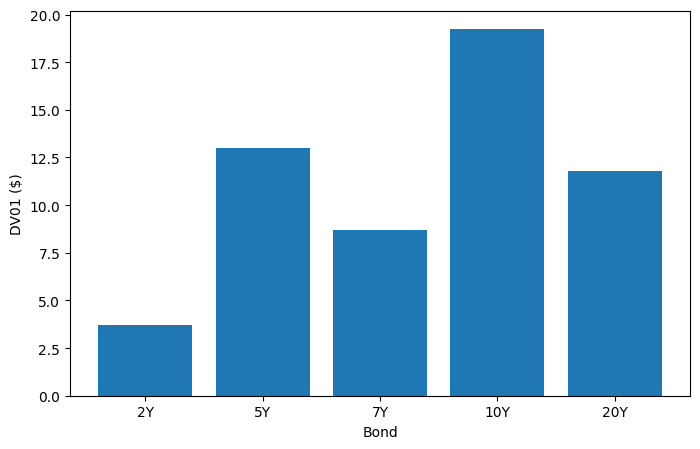

In [77]:
plt.figure(figsize=(8,5))

plt.bar(portfolio["Bond"], portfolio["DV01"])

plt.xlabel("Bond")
plt.ylabel("DV01 ($)")

In [ ]:
# Portfolio duration
portfolio["Duration"] = portfolio.apply(
    lambda row: modified_duration(
        row["Maturity"],
        row["Coupon"]
    ),
    axis=1
)

portfolio["Convexity"] = portfolio.apply(
    lambda row: convexity(
        row["Maturity"],
        row["Coupon"]
    ),
    axis=1
)

In [81]:
# Portfolio statistics
portfolio_duration = np.sum(
    portfolio["Weight"] * portfolio["Modified Duration"]
)

portfolio_convexity = np.sum(
    portfolio["Weight"] * portfolio["Convexity"]
)

portfolio_dv01 = portfolio["DV01"].sum()

base_price = portfolio["Market Value"].sum()

In [ ]:
def price_portfolio(portfolio, curve):

    total = 0

    for _, row in portfolio.iterrows():

        price = price_bond_curve(
            row["Maturity"],
            row["Coupon"],
            curve
        )

        total += (
            price
            * row["Face"]
            / 100
        )

    return total


np.float64(9928140.249927653)

In [85]:
portfolio

,Bond,Maturity,Face,Coupon,Unit Price,Market Value,Weight,DV01,Modified Duration,Convexity
0,2Y,2,2000000.0,4.20,99.886010,1.997720e+06,0.201218,3.713706,1.899130,4.596803
1,5Y,5,3000000.0,4.27,99.554418,2.986633e+06,0.300825,13.022124,4.457606,23.205232
2,7Y,7,1500000.0,4.37,99.342777,1.490142e+06,0.150093,8.693297,5.967804,41.661562
3,10Y,10,2500000.0,4.49,98.961077,2.474027e+06,0.249193,19.236623,7.960189,75.757085
4,20Y,20,1000000.0,4.95,97.961892,9.796189e+05,0.098671,11.765707,12.326856,204.707250
